<center>
    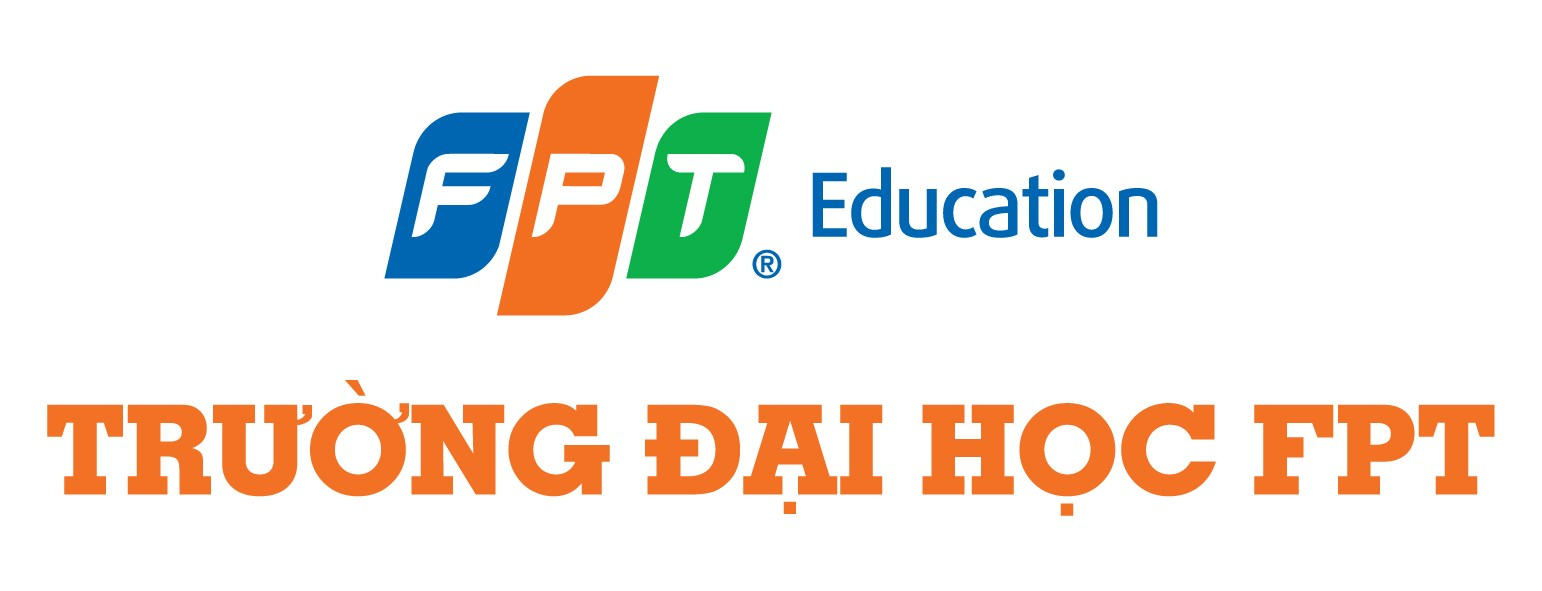
    
# Reinforcement Learning 
# Lab 1: Frozen Lake 
</center>



<br>

#### Class name: AI1902-AA

#### Student code: HE194223

#### Student name: Hoàng Hữu Quang

<br>

<a alt='AI1902'></a>
## Objectives
You will use the knowledge you have learned and implement one of the reinforcement learning algorithms yourself to solve the frozen lake problem. Note that the reinforcement learning algorithms are unlimited, you can choose any algorithm that you feel good to implement.

After completing this assignment you will be able to:

*   Describe the concept of reinforcement learning include agent, environment, action, reward ...
*   Understand about one of the RL optimization methods
*   Implement one of the reinforcement learing algorithms

Estimated time needed: **90** minutes
<h3 style='color:red;'>Note: After submitting the assignment, students will have to answer oral questions to demonstrate their understanding of the implemented algorithm.
</h5>

## 1. Introduction
<center><img src='img/frozen_lake.gif' width = 300/></center>
This environment is part of the Toy Text environments which contains general information about the environment.

Frozen lake involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. The player may not always move in the intended direction due to the slippery nature of the frozen lake. 

### Description
The game starts with the player at location [0,0] of the frozen lake grid world with the goal located at far extent of the world e.g. [3,3] for the 4x4 environment.

Holes in the ice are distributed in set locations when using a pre-determined map or in random locations when a random map is generated.

The player makes moves until they reach the goal or fall in a hole.

The lake is slippery (unless disabled) so the player may move perpendicular to the intended direction sometimes (see is_slippery).

Randomly generated worlds will always have a path to the goal.

Elf and stool from https://franuka.itch.io/rpg-snow-tileset. All other assets by Mel Tillery http://www.cyaneus.com/.

### Action Space
The action shape is (1,) in the range {0, 3} indicating which direction to move the player.

- 0: Move left
- 1: Move down
- 2: Move right
- 3: Move up

### Observation Space
The observation is a value representing the player’s current position as current_row * nrows + current_col (where both the row and col start at 0).

For example, the goal position in the 6x6 map can be calculated as follows: 5 * 6 + 5 = 35. The number of possible observations is dependent on the size of the map.

The observation is returned as an int().

### Starting State
The episode starts with the player in state [0] (location [0, 0]).

Rewards
Reward schedule:

- Reach goal: +1
- Reach hole: 0
- Reach frozen: 0

### Episode End
The episode ends if the following happens:

- Termination:

    1. The player moves into a hole.

    2. The player reaches the goal at max(nrow) * max(ncol) - 1 (location [max(nrow)-1, max(ncol)-1]).

- Truncation (when using the time_limit wrapper):

    1. The length of the episode is 100 for 4x4 environment, 200 for FrozenLake8x8-v1 environment.

### Information
step() and reset() return a dict with the following keys:

p - transition probability for the state.

See is_slippery for transition probability information.

### Arguments
```python
import gymnasium as gym
gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=True)
desc=None: Used to specify maps non-preloaded maps.
```
Specify a custom map.

```python
desc = [
        "SFFHFF",
        "FFFFFF",
        "FHFFHH",
        "FFHFFF",
        "HFFFFH",
        "FFHFFG",
    ]
gym.make('FrozenLake-v1', desc=desc)
```
If `desc=None` then `map_name` will be used. If both desc and map_name are None a random 8x8 map with 80% of locations frozen will be generated.

`is_slippery=True`: If true the player will move in intended direction with probability of 1/3 else will move in either perpendicular direction with equal probability of 1/3 in both directions.

For example, if action is left and is_slippery is True, then:

- P(move left)=1/3
- P(move up)=1/3
- P(move down)=1/3

### Results
After optimization with `is_slippery=False`, use `plot_policy` function to draw the policy to visual policy and evaluate the learned policy. 

**Note that:**
<div style="display:block;"><img src='img/termial.jpg' width = 40/> is the terminal state and the state value at terminal state should be [0, 0, 0, 0]</div>

<div style="display:block;"><img src='img/state_policy.jpg' width = 40/> is the policy of normal state, and agent will choose down or right to do the action. The state value should be [0, 0.5, 0.5, 0]</div>



Try yourself to find out what's optimal policy if  `is_slippery=True`

In [10]:
#!pip install gym
#pip install gymnasium[toy_text]

In [11]:
import numpy as np
import gymnasium as gym
from plot_utils import plot_policy


In [12]:
world_size = [6, 6]
desc=[
    "SFFHFF",
    "FFFFFF",
    "FHFFHH",
    "FFHFFF",
    "HFFFFH",
    "FFHFFG",
]

In [13]:
env=gym.make('FrozenLake-v1', desc=desc, render_mode="human", is_slippery=False)

start = env.reset()
print('Initial state of the system', start)
sample_step = 10
for i in range(sample_step):
    action  = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    if(terminated or truncated):
        start = env.reset()

env.render()
env.close()

Initial state of the system (0, {'prob': 1})


In [14]:
# START YOUR CODE HERE ###
# Feel free to add more cells

In [15]:
class Agent:
    def __init__(self, env, gamma=0.9):
        self.env = env
        self.gamma = gamma
        self.V = np.zeros(env.observation_space.n)
        self.policy = np.ones((env.observation_space.n, env.action_space.n)) / env.action_space.n
        self.terminals = [
            s for s in range(env.observation_space.n)
            if all(
                all(done for prob, next_state, reward, done in env.unwrapped.P[s][a])
                for a in range(env.action_space.n)
            )
        ]

    def action_value(self, s, a):
        return sum(
            prob * (reward + self.gamma * self.V[next_state])
            for prob, next_state, reward, done in self.env.unwrapped.P[s][a]
        )

    def evaluate_policy(self, theta=1e-8):
        while True:
            delta = 0
            for s in range(self.env.observation_space.n):
                if s in self.terminals:
                    continue
                v = self.V[s]
                self.V[s] = sum(
                    self.policy[s, a] * self.action_value(s, a)
                    for a in range(self.env.action_space.n)
                )
                delta = max(delta, abs(v - self.V[s]))
            if delta < theta:
                break

    def improve_policy(self):
        stable = True
        for s in range(self.env.observation_space.n):
            if s in self.terminals:
                self.policy[s] = np.zeros(self.env.action_space.n)
                continue
            old_action = np.argmax(self.policy[s])
            action_values = np.array([
                self.action_value(s, a)
                for a in range(self.env.action_space.n)
            ])
            best_value = np.max(action_values)
            best = np.where(np.isclose(action_values, best_value))[0]
            new_policy = np.zeros(self.env.action_space.n)
            new_policy[best] = 1.0 / len(best)
            self.policy[s] = new_policy
            if old_action not in best:
                stable = False
        return stable

    def policy_iteration(self, theta=1e-8):
        iterations = 0
        while True:
            self.evaluate_policy(theta)
            if self.improve_policy():
                break
            iterations += 1
        self.iterations = iterations
        return self.policy

    def policy_iteration_debug(self, theta=1e-6, max_iterations=100):
        """Policy iteration with iteration counter for debugging."""
        iterations = 0
        while iterations < max_iterations:
            self.evaluate_policy(theta)
            if self.improve_policy():
                break
            iterations += 1
        self.iterations = iterations
        return self.policy

Value function (6x6 grid):
[[0.38742049 0.43046721 0.4782969  0.         0.4782969  0.43046721]
 [0.43046721 0.4782969  0.531441   0.59049    0.531441   0.4782969 ]
 [0.4782969  0.         0.59049    0.6561     0.         0.        ]
 [0.531441   0.59049    0.         0.729      0.81       0.729     ]
 [0.         0.6561     0.729      0.81       0.9        0.        ]
 [0.531441   0.59049    0.         0.9        1.         0.        ]]


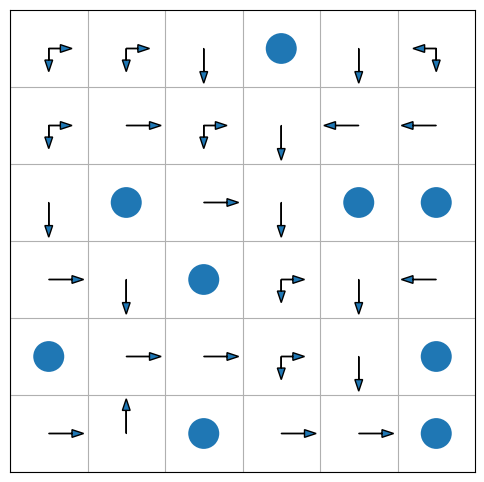

In [16]:
### DRAW POLICY WITH is_slippery=False ###

env = gym.make('FrozenLake-v1', desc=desc, render_mode="human", is_slippery=False)
agent = Agent(env)
agent.policy_iteration()

print("Value function (6x6 grid):")
print(agent.V.reshape((6,6)))

# actions: left - 0, down - 1, right - 2, up- 3
arrows = {"0":(-1,0), "1":(0,-1), "2":(1,0), "3":(0,1)}
policy = np.array(agent.policy).reshape((6,6,4))
plot_policy(policy, arrows)
env.close()

In [17]:
### TRY TO FIND AND DRAW POLICY WITH is_slippery=True FOR YOURSELF ###

Value function with slippery=True (6x6 grid):
[[0.00749288 0.00969206 0.0119279  0.         0.00899109 0.00770665]
 [0.00779134 0.01068694 0.01813971 0.0262598  0.0132726  0.0089911 ]
 [0.00719279 0.         0.02227802 0.05612036 0.         0.        ]
 [0.00899184 0.01378818 0.         0.13853005 0.15564077 0.06670319]
 [0.         0.03696876 0.08609234 0.25000572 0.31356933 0.        ]
 [0.0175115  0.02334868 0.         0.381253   0.63958462 0.        ]]


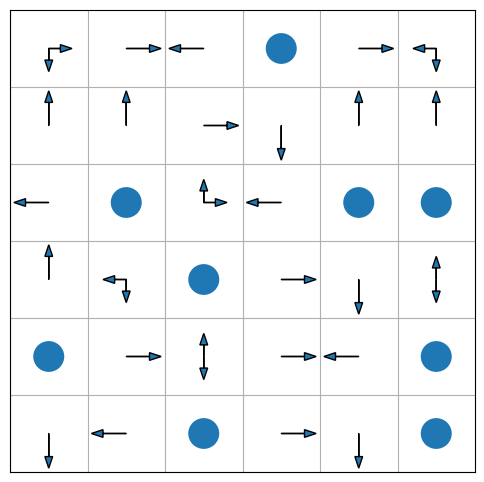

In [18]:
env2 = gym.make('FrozenLake-v1', desc=desc, render_mode="human", is_slippery=True)
agent2 = Agent(env2)
agent2.policy_iteration()

print("Value function with slippery=True (6x6 grid):")
print(agent2.V.reshape((6,6)))

# actions: left - 0, down - 1, right - 2, up- 3
arrows = {"0":(-1,0), "1":(0,-1), "2":(1,0), "3":(0,1)}
policy2 = np.array(agent2.policy).reshape((6,6,4))

plot_policy(policy2, arrows)
env2.close()